# Ideal y0 and dy ranges that create a small difference from the absoulute intersection for both apporximations


<function matplotlib.pyplot.show(close=None, block=None)>

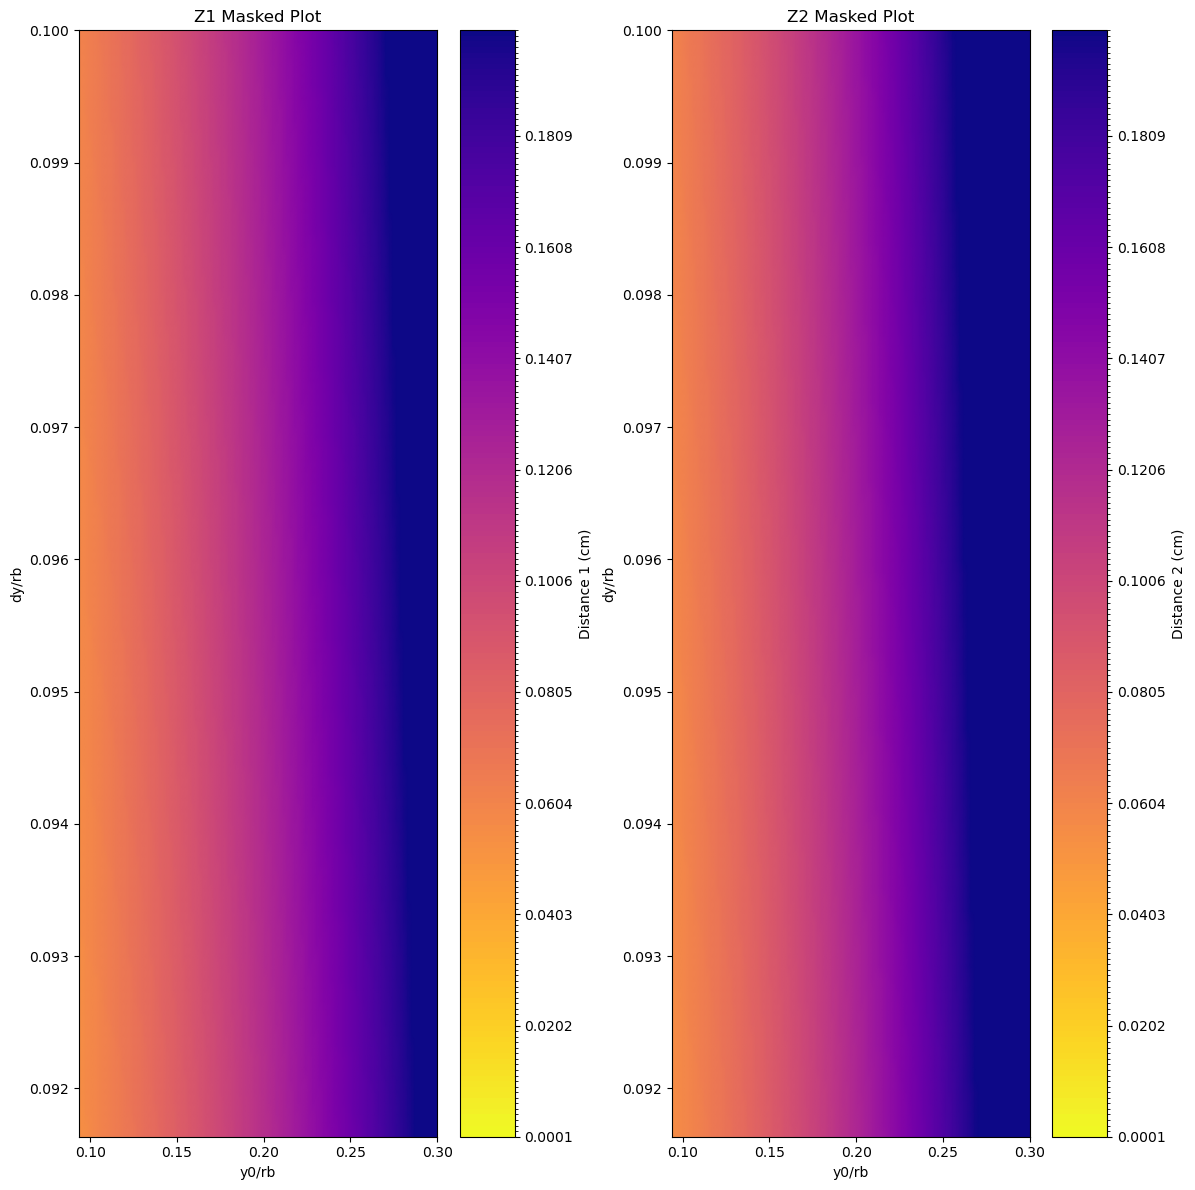

In [1]:
#Bryson Mariano
#6/3/2026

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from matplotlib.colors import BoundaryNorm

#Universal Parameters
me    = 9.1093837 * 10 ** (-31)  #kg
c     = 299792458.0              #m/s
ne    = 1 * 10.0**15 *10**6                 #number density
e0    = 8.85418782 * 10**(-12)   #m^-3 kg^-1s^4 A^2
e     = 1.60217663 * 10**(-19)   #coulombs
wp    = ((ne*e**2)/(me*e0)) ** (1/2)
#Define Parameters
gamma = 110                      #Unitless
k     = 0.475 *me*wp**2          #kg/s^2
rb    = 0.65 *c/wp               #c/omega_p   
px    = 110 *me*c                #mec

f0=((px)**2) / (gamma * me * k)
##########################################################################################################3

L = 0.3 * rb 
gridsize = 100

# Keep base coordinates pristine
y0_vals = np.linspace(0.00001, L, gridsize)[1:]
dy_vals = np.linspace(0.00001, L-0.2*rb, gridsize)[1:]

y0, dy = np.meshgrid(y0_vals, dy_vals, sparse=False)

# Clean, separate tracking matrix for the coordinate layout calculations
y0_rb = y0 / rb
dy_rb = dy / rb

# Mathematical functions 
def f_cyl(i):
    inside_sqrt = 1 - (i / rb)**2
    safe_sqrt = np.where(inside_sqrt > 0, np.sqrt(inside_sqrt), 1e-10) # Small float prevents 0 division
    return (f0 / (2 * rb) * 1 / safe_sqrt)

def f_cylprime(i):
    inside_power = 1 - (i / rb)**2
    safe_power = np.where(inside_power > 0, inside_power**(-3/2), 1e-10)
    return (f0 / (2 * rb) * safe_power * (i / rb**2))
  
# calculations 
f_Tilda = f_cyl(y0) * f_cyl(y0 + dy) / (f_cyl(y0) - y0 * (f_cyl(y0 + dy) - f_cyl(y0)) / dy) 
Intersect_y = -(y0 / (f_cyl(y0))) * f_Tilda + y0

f_Tilda2 = f_cyl(y0) / (1 - y0 * (f_cylprime(y0) / f_cyl(y0)))
Intersect_y2 = -(y0 / (f_cyl(y0))) * f_Tilda2 + y0

f_Tilda3 = f_cyl(y0) * (1 + y0 * (f_cylprime(y0) / f_cyl(y0))) 
Intersect_y3 = -(y0 / (f_cyl(y0))) * f_Tilda3 + y0

# Distance Matrix
dist1_cm = np.sqrt((f_Tilda2 - f_Tilda)**2 + (Intersect_y2 - Intersect_y)**2) * 100
dist2_cm = np.sqrt((f_Tilda3 - f_Tilda)**2 + (Intersect_y3 - Intersect_y)**2) * 100

# Apply the NaN filter ONLY to the color maps 
Z1_masked = np.where(y0 + dy < rb, np.abs(dist1_cm), np.nan)
Z2_masked = np.where(y0 + dy < rb, np.abs(dist2_cm), np.nan)


#######################

mymin =0.0001
mymax =0.2

#######################

levels = np.linspace(mymin, mymax, 200)

norm = BoundaryNorm(levels, ncolors=256)

plt.figure(figsize=(12, 12))
plt.subplot(1, 2, 1)

plt.pcolormesh(y0_rb, dy_rb, Z1_masked,  cmap='plasma_r', norm=norm, shading='gouraud')
plt.colorbar(label='Distance 1 (cm)')
plt.xlabel('y0/rb')
plt.ylabel('dy/rb')
plt.title('Z1 Masked Plot')

plt.subplot(1, 2, 2)
plt.pcolormesh(y0_rb, dy_rb, Z2_masked, cmap='plasma_r',  norm=norm, shading='gouraud')
plt.colorbar(label='Distance 2 (cm)')
plt.xlabel('y0/rb')
plt.ylabel('dy/rb')
plt.title('Z2 Masked Plot')

plt.tight_layout()
plt.show